In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ============================================================
# 🔥 FINAL COMPLETE ONE-CELL CODE
# 🔥 LATENT DIFFUSION MODEL (256x256)
## ============================================================

import torch, os, math
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from torchvision.utils import save_image
from PIL import Image
from tqdm import tqdm
from torch.amp import autocast, GradScaler
import torch.nn.functional as F

# -----------------------------
# ✅ CONFIG
# -----------------------------
IMG_SIZE   = 256        # keep
LATENT_DIM = 256        # 🔥 REDUCE (very important)
BATCH_SIZE = 8          # keep (safe)
EPOCHS     = 300        # 🔥 REDUCE
LR         = 1e-4       # 🔥 slightly lower
TIMESTEPS  = 1000       # keep

DATA_PATH = "/content/drive/MyDrive/POTATODATASET/Early_blight"
SAVE_DIR = "/content/drive/MyDrive/PotatoEBLDMoutput"

# -----------------------------
# ✅ DEVICE
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
scaler = GradScaler()
os.makedirs(SAVE_DIR, exist_ok=True)

# -----------------------------
# ✅ DATASET
# -----------------------------
class SingleClassImageDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.paths = [
            os.path.join(root_dir, f)
            for f in os.listdir(root_dir)
            if f.lower().endswith((".png", ".jpg", ".jpeg"))
        ]
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, 0

transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize([0.5]*3, [0.5]*3)
])

dataset = SingleClassImageDataset(DATA_PATH, transform)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

# -----------------------------
# ✅ MODELS
# -----------------------------
class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1), nn.ReLU(),           # 128
            nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(), # 64
            nn.Conv2d(128, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.ReLU(),# 32
            nn.Conv2d(256, 512, 4, 2, 1), nn.BatchNorm2d(512), nn.ReLU(),# 16
            nn.Conv2d(512, 512, 4, 2, 1), nn.ReLU(),        # 8
            nn.Flatten(),
            nn.Linear(512 * 8 * 8, latent_dim)
        )

    def forward(self, x):
        return self.net(x)

class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 512 * 8 * 8)
        self.net = nn.Sequential(
            nn.ConvTranspose2d(512, 512, 4, 2, 1), nn.BatchNorm2d(512), nn.ReLU(), # 16
            nn.ConvTranspose2d(512, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.ReLU(), # 32
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(), # 64
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(),   # 128
            nn.ConvTranspose2d(64, 3, 4, 2, 1), nn.Tanh()                           # 256
        )

    def forward(self, z):
        return self.net(self.fc(z).view(-1, 512, 8, 8))

class LatentUNet(nn.Module):
    def __init__(self, latent_dim, timesteps):
        super().__init__()
        self.time_embed = nn.Embedding(timesteps, latent_dim)
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 1024), nn.ReLU(),
            nn.Linear(1024, 1024), nn.ReLU(),
            nn.Linear(1024, latent_dim)
        )

    def forward(self, x, t):
        return self.net(x + self.time_embed(t))

# -----------------------------
# ✅ INIT
# -----------------------------
encoder = Encoder(LATENT_DIM).to(device)
decoder = Decoder(LATENT_DIM).to(device)
unet = LatentUNet(LATENT_DIM, TIMESTEPS).to(device)

optimizer = optim.Adam(
    list(encoder.parameters()) +
    list(decoder.parameters()) +
    list(unet.parameters()),
    lr=LR
)

# -----------------------------
# ✅ DIFFUSION SCHEDULE
# -----------------------------
betas = torch.linspace(1e-4, 0.02, TIMESTEPS).to(device)
alphas = 1. - betas
alpha_hat = torch.cumprod(alphas, dim=0)

# -----------------------------
# ✅ KL LOSS
# -----------------------------
def kl_divergence(z):
    return 0.5 * torch.mean(z.pow(2))

# -----------------------------
# 🚀 TRAINING
# -----------------------------
print("\n🚀 Starting Latent Diffusion Training...\n")

for epoch in range(EPOCHS):
    encoder.train(); decoder.train(); unet.train()
    pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for imgs, _ in pbar:
        imgs = imgs.to(device)

        with autocast(device_type=device.type):
            # ---- Autoencoder ----
            z = encoder(imgs)
            recon = decoder(z)
            recon_loss = F.mse_loss(recon, imgs)
            kl_loss = kl_divergence(z)
            ae_loss = recon_loss + 0.001 * kl_loss

            # ---- Diffusion ----
            t = torch.randint(0, TIMESTEPS, (z.size(0),), device=device)
            noise = torch.randn_like(z)
            ah = alpha_hat[t].unsqueeze(1)
            noisy_z = torch.sqrt(ah) * z + torch.sqrt(1 - ah) * noise
            pred_noise = unet(noisy_z, t)
            diff_loss = F.mse_loss(pred_noise, noise)

            total_loss = ae_loss + diff_loss

        optimizer.zero_grad()
        scaler.scale(total_loss).backward()
        scaler.step(optimizer)
        scaler.update()

        pbar.set_postfix(loss=f"{total_loss.item():.4f}")

    # -----------------------------
    # 💾 SAVE & SAMPLE
    # -----------------------------
    if (epoch + 1) % 20 == 0:
        encoder.eval(); decoder.eval()
        with torch.no_grad():
            sample_imgs, _ = next(iter(dataloader))
            z_sample = encoder(sample_imgs.to(device))
            samples = decoder(z_sample)
            save_image((samples + 1) / 2,
                       f"{SAVE_DIR}/sample_epoch_{epoch+1}.png",
                       nrow=4)

            torch.save(encoder.state_dict(), f"{SAVE_DIR}/encoder_{epoch+1}.pth")
            torch.save(decoder.state_dict(), f"{SAVE_DIR}/decoder_{epoch+1}.pth")
            torch.save(unet.state_dict(), f"{SAVE_DIR}/unet_{epoch+1}.pth")

        print(f"✅ Saved samples & checkpoints at epoch {epoch+1}")

print("\n🎉 Training Complete!")



🚀 Starting Latent Diffusion Training...



Epoch 20/300: 100%|██████████| 125/125 [00:02<00:00, 49.73it/s, loss=0.7451]


✅ Saved samples & checkpoints at epoch 20


Epoch 40/300: 100%|██████████| 125/125 [00:02<00:00, 49.78it/s, loss=0.6213]


✅ Saved samples & checkpoints at epoch 40


...

✅ Saved samples & checkpoints at epoch 260


Epoch 280/300: 100%|██████████| 125/125 [00:02<00:00, 49.54it/s, loss=0.3297]


✅ Saved samples & checkpoints at epoch 280


Epoch 300/300: 100%|██████████| 125/125 [00:02<00:00, 49.48it/s, loss=0.4524]


✅ Saved samples & checkpoints at epoch 300

🎉 Training Complete!


In [ ]:
# ============================================================
# 🔥 LDM GENERATION + FULL EVALUATION (256x256)

# 🔥 5000 IMAGES
# ============================================================

# -----------------------------
# 📦 IMPORTS
# -----------------------------
import os, zipfile
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import trange
from itertools import cycle
from PIL import Image
from scipy import linalg
from sklearn.decomposition import PCA

import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.utils import save_image
import torchvision.transforms as T
import torchvision.models as models

# -----------------------------
# ⚙️ CONFIG
# -----------------------------
IMG_SIZE = 256
LATENT_DIM = 256
TIMESTEPS = 1000
NUM_GEN = 5000

DATA_PATH = "/content/drive/MyDrive/POTATODATASET/Early_blight"
OUTPUT_DIR = "/content/drive/MyDrive/POTATODATASET/EB_LDM_EVAL"

ENCODER_PATH = "/content/drive/MyDrive/PotatoEBLDMoutput/encoder_300.pth"
DECODER_PATH = "/content/drive/MyDrive/PotatoEBLDMoutput/decoder_300.pth"
UNET_PATH    = "/content/drive/MyDrive/PotatoEBLDMoutput/unet_300.pth"

os.makedirs(OUTPUT_DIR, exist_ok=True)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------
# 📊 DIFFUSION SCHEDULE
# -----------------------------
betas = torch.linspace(1e-4, 0.02, TIMESTEPS).to(DEVICE)
alphas = 1. - betas
alpha_hat = torch.cumprod(alphas, dim=0)

# -----------------------------
# 📁 DATASET
# -----------------------------
class SingleClassImageDataset(Dataset):
    def __init__(self, root, transform):
        self.paths = [os.path.join(root, f) for f in os.listdir(root)
                      if f.lower().endswith((".png",".jpg",".jpeg"))]
        self.transform = transform

    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        return self.transform(img), 0

img_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize([0.5]*3, [0.5]*3)
])

fid_tf = T.Compose([
    T.Resize((299, 299)),
    T.ToTensor(),
    T.Normalize([0.5]*3, [0.5]*3)
])

real_loader = DataLoader(
    SingleClassImageDataset(DATA_PATH, fid_tf),
    batch_size=32, shuffle=False
)

# -----------------------------
# 🧠 MODELS
# -----------------------------
class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256, 512, 4, 2, 1), nn.BatchNorm2d(512), nn.ReLU(),
            nn.Conv2d(512, 512, 4, 2, 1), nn.ReLU(),
            nn.Flatten(),
            nn.Linear(512*8*8, latent_dim)
        )
    def forward(self, x): return self.net(x)

class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 512*8*8)
        self.net = nn.Sequential(
            nn.ConvTranspose2d(512, 512, 4, 2, 1), nn.BatchNorm2d(512), nn.ReLU(),
            nn.ConvTranspose2d(512, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64, 3, 4, 2, 1), nn.Tanh()
        )
    def forward(self, z): return self.net(self.fc(z).view(-1, 512, 8, 8))

class LatentUNet(nn.Module):
    def __init__(self, latent_dim, timesteps):
        super().__init__()
        self.time_embed = nn.Embedding(timesteps, latent_dim)
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 1024), nn.ReLU(),
            nn.Linear(1024, 1024), nn.ReLU(),
            nn.Linear(1024, latent_dim)
        )
    def forward(self, x, t):
        return self.net(x + self.time_embed(t))

encoder = Encoder(LATENT_DIM).to(DEVICE)
decoder = Decoder(LATENT_DIM).to(DEVICE)
unet = LatentUNet(LATENT_DIM, TIMESTEPS).to(DEVICE)

# -----------------------------
# 🔑 LOAD MODELS
# -----------------------------
encoder.load_state_dict(torch.load(ENCODER_PATH, map_location=DEVICE))
decoder.load_state_dict(torch.load(DECODER_PATH, map_location=DEVICE))
unet.load_state_dict(torch.load(UNET_PATH, map_location=DEVICE), strict=False)  # ignore key mismatch

encoder.eval(); decoder.eval(); unet.eval()
print("✅ Models loaded")

# -----------------------------
# 🎨 IMAGE GENERATION (5000)
# -----------------------------
count = 0
loader = cycle(DataLoader(
    SingleClassImageDataset(DATA_PATH, img_tf),
    batch_size=8, shuffle=True
))

with torch.no_grad():
    for imgs, _ in loader:
        z = encoder(imgs.to(DEVICE))
        out = (decoder(z) + 1)/2
        for img in out:
            save_image(img, f"{OUTPUT_DIR}/gen_{count:05}.png")
            count += 1
            if count >= NUM_GEN: break
        if count >= NUM_GEN: break
print(f"✅ Generated {NUM_GEN} images")

# -----------------------------
# 📊 SSIM
# -----------------------------
from skimage.metrics import structural_similarity as ssim

real_imgs = sorted(os.listdir(DATA_PATH))[:100]
gen_imgs  = sorted(os.listdir(OUTPUT_DIR))[:100]

ssim_scores = []
for r,g in zip(real_imgs, gen_imgs):
    r_img = np.array(Image.open(os.path.join(DATA_PATH,r)).resize((256,256)))
    g_img = np.array(Image.open(os.path.join(OUTPUT_DIR,g)))
    ssim_scores.append(ssim(r_img, g_img, channel_axis=2))

print(f"✅ SSIM: {np.mean(ssim_scores):.4f}")

plt.figure(figsize=(6,4))
plt.hist(ssim_scores, bins=20)
plt.title("SSIM Histogram")
plt.xlabel("SSIM")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

# -----------------------------
# 📊 LPIPS
# -----------------------------
!pip install lpips --quiet
import lpips
lpips_fn = lpips.LPIPS(net="alex").to(DEVICE)

imgs = [img_tf(Image.open(os.path.join(OUTPUT_DIR,f))).unsqueeze(0).to(DEVICE)
        for f in gen_imgs[:50]]

lpips_vals = []
for i in range(len(imgs)):
    for j in range(i+1,len(imgs)):
        lpips_vals.append(lpips_fn(imgs[i], imgs[j]).item())

print(f"✅ LPIPS: {np.mean(lpips_vals):.4f}")

plt.figure(figsize=(6,4))
plt.hist(lpips_vals, bins=30)
plt.title("LPIPS Diversity")
plt.xlabel("LPIPS Distance")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

# -----------------------------
# 📊 FID + PCA
# -----------------------------
inception = models.inception_v3(pretrained=True, transform_input=False).to(DEVICE)
inception.fc = nn.Identity()
inception.eval()

def get_feats(loader):
    feats = []
    with torch.no_grad():
        for x,_ in loader:
            feats.append(inception(x.to(DEVICE)).cpu().numpy())
    return np.concatenate(feats)

gen_loader = DataLoader(
    SingleClassImageDataset(OUTPUT_DIR, fid_tf),
    batch_size=32, shuffle=False
)

r = get_feats(real_loader)
g = get_feats(gen_loader)

mu1, mu2 = r.mean(0), g.mean(0)
s1, s2 = np.cov(r,rowvar=False), np.cov(g,rowvar=False)
fid = np.sum((mu1-mu2)**2) + np.trace(s1+s2-2*linalg.sqrtm(s1@s2).real)
print(f"✅ FID: {fid:.2f}")

# PCA Scatter
pca = PCA(n_components=2)
proj = pca.fit_transform(np.concatenate([r,g],axis=0))

plt.figure(figsize=(6,6))
plt.scatter(proj[:len(r),0], proj[:len(r),1], s=8, label="Real")
plt.scatter(proj[len(r):,0], proj[len(r):,1], s=8, label="Generated")
plt.title("FID Feature Space (PCA)")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# 📦 ZIP OUTPUT
# -----------------------------
zip_path = OUTPUT_DIR + ".zip"
with zipfile.ZipFile(zip_path,"w") as z:
    for f in os.listdir(OUTPUT_DIR):
        z.write(os.path.join(OUTPUT_DIR,f), f)
print(f"📦 Outputs zipped: {zip_path}")


In [ ]:
# ============================================================
# 🔥 ENHANCED LDM: AE + KL + DDPM + Perceptual + LPIPS + UNet Fusion
# Dataset: Potato Early Blight (256x256)
# ============================================================
!pip install lpips

import torch, os
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from torchvision.utils import save_image
from PIL import Image
from tqdm import tqdm
import torch.nn.functional as F
from torch.amp import autocast, GradScaler

# -----------------------------
# CONFIG
IMG_SIZE   = 256
LATENT_DIM = 256        # Must be perfect square for ConvUNet
BATCH_SIZE = 8
EPOCHS     = 100
LR         = 1e-4
TIMESTEPS  = 1000
DATA_PATH  = "/content/drive/MyDrive/POTATODATASET/Early_blight"
SAVE_DIR   = "/content/drive/MyDrive/POTATODATASET/PotatoEBLDM_Fusion"
os.makedirs(SAVE_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
scaler = GradScaler()

# -----------------------------
# DATASET
class SingleClassDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.paths = [os.path.join(root_dir,f) for f in os.listdir(root_dir)
                      if f.lower().endswith((".png",".jpg",".jpeg"))]
        self.transform = transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        if self.transform: img = self.transform(img)
        return img, 0

transform = T.Compose([T.Resize((IMG_SIZE, IMG_SIZE)),
                       T.ToTensor(),
                       T.Normalize([0.5]*3, [0.5]*3)])
dataset = SingleClassDataset(DATA_PATH, transform)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

# -----------------------------
# AUTOENCODER
class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3,64,4,2,1), nn.ReLU(),
            nn.Conv2d(64,128,4,2,1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128,256,4,2,1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256,512,4,2,1), nn.BatchNorm2d(512), nn.ReLU(),
            nn.Flatten(),
            nn.Linear(512*16*16, latent_dim)
        )
    def forward(self,x): return self.net(x)

class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 512*16*16)
        self.net = nn.Sequential(
            nn.ConvTranspose2d(512,256,4,2,1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.ConvTranspose2d(256,128,4,2,1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128,64,4,2,1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64,3,4,2,1), nn.Tanh()
        )
    def forward(self,z):
        x = self.fc(z).view(-1,512,16,16)
        return self.net(x)

# -----------------------------
# LATENT MLP UNET
class LatentMLPUNet(nn.Module):
    def __init__(self, latent_dim, timesteps):
        super().__init__()
        self.time_embed = nn.Embedding(timesteps, latent_dim)
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 1024), nn.ReLU(),
            nn.Linear(1024, 1024), nn.ReLU(),
            nn.Linear(1024, latent_dim)
        )
    def forward(self, x, t):
        return self.net(x + self.time_embed(t))

# -----------------------------
# Lightweight ConvUNet Fusion
class ConvUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1,64,3,1,1)
        self.conv2 = nn.Conv2d(64,64,3,1,1)
        self.deconv1 = nn.ConvTranspose2d(64,64,3,1,1)
        self.deconv2 = nn.ConvTranspose2d(64,1,3,1,1)
    def forward(self,x,t=None):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.deconv1(x))
        x = self.deconv2(x)
        return x

# -----------------------------
# INIT MODELS & OPTIMIZER
encoder = Encoder(LATENT_DIM).to(device)
decoder = Decoder(LATENT_DIM).to(device)
latent_unet = LatentMLPUNet(LATENT_DIM,TIMESTEPS).to(device)
conv_unet = ConvUNet().to(device)

optimizer = optim.Adam(list(encoder.parameters())+
                       list(decoder.parameters())+
                       list(latent_unet.parameters())+
                       list(conv_unet.parameters()), lr=LR)

# -----------------------------
# DIFFUSION SCHEDULE
betas = torch.linspace(1e-4,0.02,TIMESTEPS).to(device)
alphas = 1-betas
alpha_hat = torch.cumprod(alphas,dim=0)

# -----------------------------
# LPIPS
import lpips
lpips_fn = lpips.LPIPS(net='alex').to(device)

# -----------------------------
# VGG PERCEPTUAL LOSS
from torchvision.models import vgg16
vgg = vgg16(pretrained=True).features.eval().to(device)
for p in vgg.parameters(): p.requires_grad=False
def perceptual_loss(x,y):
    return F.mse_loss(vgg(x),vgg(y))

# -----------------------------
# TRAINING
print("\n🚀 Starting Enhanced LDM Training...\n")
for epoch in range(EPOCHS):
    encoder.train(); decoder.train(); latent_unet.train(); conv_unet.train()
    pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for imgs,_ in pbar:
        imgs = imgs.to(device)

        with autocast(device_type=device.type):
            # Autoencoder + KL
            z = encoder(imgs)
            recon = decoder(z)
            ae_loss = F.mse_loss(recon, imgs)
            kl_loss = 0.5*torch.mean(z**2)

            # Diffusion
            t = torch.randint(0,TIMESTEPS,(imgs.size(0),),device=device)
            noise = torch.randn_like(z)
            ah = alpha_hat[t].unsqueeze(1)
            noisy_z = torch.sqrt(ah)*z + torch.sqrt(1-ah)*noise

            # Latent MLP UNet
            pred_noise_mlp = latent_unet(noisy_z,t)

            # ConvUNet fusion
            H = W = int(LATENT_DIM**0.5)
            pred_noise_conv = conv_unet(noisy_z.view(imgs.size(0),1,H,W))
            pred_noise_conv = pred_noise_conv.view(imgs.size(0),LATENT_DIM)

            # Combined diffusion loss
            pred_noise = pred_noise_mlp + pred_noise_conv
            diff_loss = F.mse_loss(pred_noise, noise)

            # Perceptual + LPIPS
            perc_loss = perceptual_loss(recon, imgs)
            lpips_loss = lpips_fn(recon, imgs).mean()

            # Total loss
            total_loss = ae_loss + 0.001*kl_loss + diff_loss + 0.1*perc_loss + 0.1*lpips_loss

        optimizer.zero_grad()
        scaler.scale(total_loss).backward()
        scaler.step(optimizer)
        scaler.update()
        pbar.set_postfix(loss=f"{total_loss.item():.4f}")

    # Save checkpoints & sample
    if (epoch+1) % 20 == 0:
        encoder.eval(); decoder.eval()
        with torch.no_grad():
            sample_imgs,_ = next(iter(dataloader))
            z_sample = encoder(sample_imgs.to(device))
            samples = decoder(z_sample)
            save_image((samples+1)/2, f"{SAVE_DIR}/sample_epoch_{epoch+1}.png", nrow=4)
            torch.save(encoder.state_dict(), f"{SAVE_DIR}/encoder_{epoch+1}.pth")
            torch.save(decoder.state_dict(), f"{SAVE_DIR}/decoder_{epoch+1}.pth")
            torch.save(latent_unet.state_dict(), f"{SAVE_DIR}/latent_unet_{epoch+1}.pth")
            torch.save(conv_unet.state_dict(), f"{SAVE_DIR}/conv_unet_{epoch+1}.pth")
        print(f"✅ Saved samples & checkpoints at epoch {epoch+1}")

print("\n🎉 Training Complete!")


In [ ]:
# ============================================================
# 🔥 RESUMABLE ENHANCED LDM TRAINING (UP TO 300 EPOCHS)
# Dataset: Potato Early Blight (256x256)
# ============================================================

!pip install lpips --quiet

import torch, os
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from torchvision.utils import save_image
from PIL import Image
from tqdm import tqdm
import torch.nn.functional as F
from torch.amp import autocast, GradScaler
import lpips
from torchvision.models import vgg16

# -----------------------------
# CONFIG
IMG_SIZE   = 256
LATENT_DIM = 256
BATCH_SIZE = 8
TOTAL_EPOCHS = 300
SAVE_INTERVAL = 20
LR         = 1e-4
TIMESTEPS  = 1000
DATA_PATH  = "/content/drive/MyDrive/POTATODATASET/Early_blight"
SAVE_DIR   = "/content/drive/MyDrive/POTATODATASET/PotatoEBLDM_Fusion"
os.makedirs(SAVE_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
scaler = GradScaler()

# -----------------------------
# DATASET
class SingleClassDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.paths = [os.path.join(root_dir,f) for f in os.listdir(root_dir)
                      if f.lower().endswith((".png",".jpg",".jpeg"))]
        self.transform = transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        if self.transform: img = self.transform(img)
        return img, 0

transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize([0.5]*3, [0.5]*3)
])

dataset = SingleClassDataset(DATA_PATH, transform)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

# -----------------------------
# MODELS
class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3,64,4,2,1), nn.ReLU(),
            nn.Conv2d(64,128,4,2,1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128,256,4,2,1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256,512,4,2,1), nn.BatchNorm2d(512), nn.ReLU(),
            nn.Flatten(),
            nn.Linear(512*16*16, latent_dim)
        )
    def forward(self,x): return self.net(x)

class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 512*16*16)
        self.net = nn.Sequential(
            nn.ConvTranspose2d(512,256,4,2,1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.ConvTranspose2d(256,128,4,2,1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128,64,4,2,1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64,3,4,2,1), nn.Tanh()
        )
    def forward(self,z):
        x = self.fc(z).view(-1,512,16,16)
        return self.net(x)

class LatentMLPUNet(nn.Module):
    def __init__(self, latent_dim, timesteps):
        super().__init__()
        self.time_embed = nn.Embedding(timesteps, latent_dim)
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 1024), nn.ReLU(),
            nn.Linear(1024, 1024), nn.ReLU(),
            nn.Linear(1024, latent_dim)
        )
    def forward(self, x, t):
        return self.net(x + self.time_embed(t))

class ConvUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1,64,3,1,1)
        self.conv2 = nn.Conv2d(64,64,3,1,1)
        self.deconv1 = nn.ConvTranspose2d(64,64,3,1,1)
        self.deconv2 = nn.ConvTranspose2d(64,1,3,1,1)
    def forward(self,x,t=None):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.deconv1(x))
        x = self.deconv2(x)
        return x

# -----------------------------
# INIT
encoder = Encoder(LATENT_DIM).to(device)
decoder = Decoder(LATENT_DIM).to(device)
latent_unet = LatentMLPUNet(LATENT_DIM, TIMESTEPS).to(device)
conv_unet = ConvUNet().to(device)

optimizer = optim.Adam(
    list(encoder.parameters()) +
    list(decoder.parameters()) +
    list(latent_unet.parameters()) +
    list(conv_unet.parameters()),
    lr=LR
)

# -----------------------------
# DIFFUSION SCHEDULE
betas = torch.linspace(1e-4,0.02,TIMESTEPS).to(device)
alphas = 1 - betas
alpha_hat = torch.cumprod(alphas, dim=0)

# -----------------------------
# LPIPS + VGG Perceptual
lpips_fn = lpips.LPIPS(net='alex').to(device)
vgg = vgg16(pretrained=True).features.eval().to(device)
for p in vgg.parameters(): p.requires_grad=False
def perceptual_loss(x,y): return F.mse_loss(vgg(x),vgg(y))

# -----------------------------
# RESUME CHECKPOINTS IF AVAILABLE
start_epoch = 0
for model_name, model in [("encoder",encoder),("decoder",decoder),
                          ("latent_unet",latent_unet),("conv_unet",conv_unet)]:
    ckpts = [f for f in os.listdir(SAVE_DIR) if f.startswith(model_name)]
    if ckpts:
        latest = sorted(ckpts, key=lambda x:int(x.split('_')[-1].split('.')[0]))[-1]
        model.load_state_dict(torch.load(os.path.join(SAVE_DIR,latest)))
        start_epoch = max(start_epoch, int(latest.split('_')[-1].split('.')[0]))
print(f"Resuming from epoch {start_epoch+1}")

# -----------------------------
# TRAINING LOOP
for epoch in range(start_epoch, TOTAL_EPOCHS):
    encoder.train(); decoder.train(); latent_unet.train(); conv_unet.train()
    pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{TOTAL_EPOCHS}")

    for imgs,_ in pbar:
        imgs = imgs.to(device)
        with autocast(device_type=device.type):
            # Autoencoder + KL
            z = encoder(imgs)
            recon = decoder(z)
            ae_loss = F.mse_loss(recon, imgs)
            kl_loss = 0.5*torch.mean(z**2)

            # Diffusion
            t = torch.randint(0,TIMESTEPS,(imgs.size(0),),device=device)
            noise = torch.randn_like(z)
            ah = alpha_hat[t].unsqueeze(1)
            noisy_z = torch.sqrt(ah)*z + torch.sqrt(1-ah)*noise

            # Latent MLP UNet
            pred_noise_mlp = latent_unet(noisy_z,t)

            # ConvUNet fusion
            H = W = int(LATENT_DIM**0.5)
            pred_noise_conv = conv_unet(noisy_z.view(imgs.size(0),1,H,W))
            pred_noise_conv = pred_noise_conv.view(imgs.size(0),LATENT_DIM)

            # Combined diffusion loss
            pred_noise = pred_noise_mlp + pred_noise_conv
            diff_loss = F.mse_loss(pred_noise, noise)

            # Perceptual + LPIPS
            perc_loss = perceptual_loss(recon, imgs)
            lpips_loss = lpips_fn(recon, imgs).mean()

            # Total loss
            total_loss = ae_loss + 0.001*kl_loss + diff_loss + 0.1*perc_loss + 0.1*lpips_loss

        optimizer.zero_grad()
        scaler.scale(total_loss).backward()
        scaler.step(optimizer)
        scaler.update()
        pbar.set_postfix(loss=f"{total_loss.item():.4f}")

    # Save checkpoints & samples
    if (epoch+1) % SAVE_INTERVAL == 0:
        encoder.eval(); decoder.eval()
        with torch.no_grad():
            sample_imgs,_ = next(iter(dataloader))
            z_sample = encoder(sample_imgs.to(device))
            samples = decoder(z_sample)
            save_image((samples+1)/2,
                       f"{SAVE_DIR}/sample_epoch_{epoch+1}.png",
                       nrow=4)
            for model_name, model in [("encoder",encoder),("decoder",decoder),
                                      ("latent_unet",latent_unet),("conv_unet",conv_unet)]:
                torch.save(model.state_dict(), f"{SAVE_DIR}/{model_name}_{epoch+1}.pth")
        print(f"✅ Saved samples & checkpoints at epoch {epoch+1}")

print("\n🎉 Training Complete!")


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
Resuming from epoch 101


Epoch 120/300: 100%|██████████| 125/125 [00:04<00:00, 26.43it/s, loss=0.0729]


✅ Saved samples & checkpoints at epoch 120


Epoch 140/300: 100%|██████████| 125/125 [00:04<00:00, 26.15it/s, loss=0.1166]


✅ Saved samples & checkpoints at epoch 140


...

✅ Saved samples & checkpoints at epoch 260


Epoch 280/300: 100%|██████████| 125/125 [00:04<00:00, 26.28it/s, loss=0.0605]


✅ Saved samples & checkpoints at epoch 280


Epoch 300/300: 100%|██████████| 125/125 [00:04<00:00, 26.13it/s, loss=0.0574]


✅ Saved samples & checkpoints at epoch 300

🎉 Training Complete!


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth

🚀 Starting Enhanced LDM + GAN Training...



Epoch 20/300: 100%|██████████| 125/125 [00:05<00:00, 23.82it/s, disc=0.0012, loss=0.1860]


✅ Saved samples & checkpoints at epoch 20


Epoch 40/300: 100%|██████████| 125/125 [00:05<00:00, 23.79it/s, disc=0.0003, loss=0.1120]


✅ Saved samples & checkpoints at epoch 40


...

✅ Saved samples & checkpoints at epoch 260


Epoch 280/300: 100%|██████████| 125/125 [00:05<00:00, 24.00it/s, disc=0.0001, loss=0.0523]


✅ Saved samples & checkpoints at epoch 280


Epoch 300/300: 100%|██████████| 125/125 [00:05<00:00, 23.97it/s, disc=0.0000, loss=0.0486]


✅ Saved samples & checkpoints at epoch 300


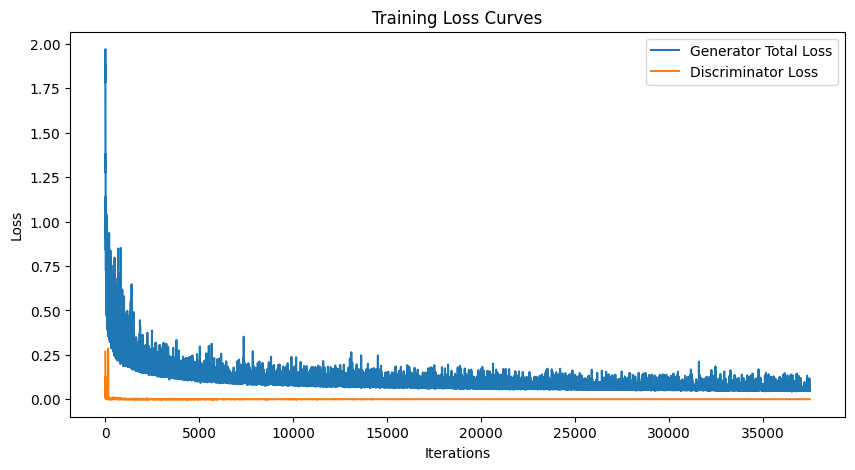


🎉 Training Complete!


In [ ]:
# ============================================================
# 🚀 Enhanced LDM + GAN Training
# Dataset: Potato Early Blight (256x256)
# AE + KL + DDPM + Perceptual + LPIPS + UNet Fusion + GAN
# ============================================================

!pip install lpips

import torch, os
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from torchvision.utils import save_image
from PIL import Image
from tqdm import tqdm
import torch.nn.functional as F
from torch.amp import autocast, GradScaler
import matplotlib.pyplot as plt
import lpips

# -----------------------------
# CONFIG
# -----------------------------
IMG_SIZE   = 256
LATENT_DIM = 256
BATCH_SIZE = 8
EPOCHS     = 300
LR         = 1e-4
TIMESTEPS  = 1000
DATA_PATH  = "/content/drive/MyDrive/POTATODATASET/Early_blight"
SAVE_DIR   = "/content/drive/MyDrive/POTATODATASET/PotatoEBLDM_FusionGAN"
os.makedirs(SAVE_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
scaler = GradScaler()

# -----------------------------
# DATASET
# -----------------------------
class SingleClassDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.paths = [os.path.join(root_dir,f) for f in os.listdir(root_dir)
                      if f.lower().endswith((".png",".jpg",".jpeg"))]
        self.transform = transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        if self.transform: img = self.transform(img)
        return img, 0

transform = T.Compose([T.Resize((IMG_SIZE, IMG_SIZE)),
                       T.ToTensor(),
                       T.Normalize([0.5]*3, [0.5]*3)])
dataset = SingleClassDataset(DATA_PATH, transform)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

# -----------------------------
# AUTOENCODER
# -----------------------------
class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3,64,4,2,1), nn.ReLU(),
            nn.Conv2d(64,128,4,2,1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128,256,4,2,1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256,512,4,2,1), nn.BatchNorm2d(512), nn.ReLU(),
            nn.Flatten(),
            nn.Linear(512*16*16, latent_dim)
        )
    def forward(self,x): return self.net(x)

class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 512*16*16)
        self.net = nn.Sequential(
            nn.ConvTranspose2d(512,256,4,2,1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.ConvTranspose2d(256,128,4,2,1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128,64,4,2,1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64,3,4,2,1), nn.Tanh()
        )
    def forward(self,z):
        x = self.fc(z).view(-1,512,16,16)
        return self.net(x)

# -----------------------------
# LATENT MLP UNET
# -----------------------------
class LatentMLPUNet(nn.Module):
    def __init__(self, latent_dim, timesteps):
        super().__init__()
        self.time_embed = nn.Embedding(timesteps, latent_dim)
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 1024), nn.ReLU(),
            nn.Linear(1024, 1024), nn.ReLU(),
            nn.Linear(1024, latent_dim)
        )
    def forward(self, x, t):
        return self.net(x + self.time_embed(t))

# -----------------------------
# ConvUNet Fusion
# -----------------------------
class ConvUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1,64,3,1,1)
        self.conv2 = nn.Conv2d(64,64,3,1,1)
        self.deconv1 = nn.ConvTranspose2d(64,64,3,1,1)
        self.deconv2 = nn.ConvTranspose2d(64,1,3,1,1)
    def forward(self,x,t=None):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.deconv1(x))
        x = self.deconv2(x)
        return x

# -----------------------------
# Discriminator (simple PatchGAN)
# -----------------------------
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3,64,4,2,1), nn.LeakyReLU(0.2),
            nn.Conv2d(64,128,4,2,1), nn.BatchNorm2d(128), nn.LeakyReLU(0.2),
            nn.Conv2d(128,256,4,2,1), nn.BatchNorm2d(256), nn.LeakyReLU(0.2),
            nn.Conv2d(256,1,4,1,0)
        )
    def forward(self,x): return self.net(x).view(x.size(0),-1).mean(1, keepdim=True)

# -----------------------------
# INIT MODELS & OPTIMIZERS
# -----------------------------
encoder = Encoder(LATENT_DIM).to(device)
decoder = Decoder(LATENT_DIM).to(device)
latent_unet = LatentMLPUNet(LATENT_DIM,TIMESTEPS).to(device)
conv_unet = ConvUNet().to(device)
discriminator = Discriminator().to(device)

optimizer = optim.Adam(list(encoder.parameters())+
                       list(decoder.parameters())+
                       list(latent_unet.parameters())+
                       list(conv_unet.parameters()), lr=LR)
opt_disc = optim.Adam(discriminator.parameters(), lr=LR)

# -----------------------------
# DIFFUSION SCHEDULE
betas = torch.linspace(1e-4,0.02,TIMESTEPS).to(device)
alphas = 1-betas
alpha_hat = torch.cumprod(alphas,dim=0)

# -----------------------------
# LPIPS
lpips_fn = lpips.LPIPS(net='alex').to(device)

# -----------------------------
# VGG Perceptual Loss
from torchvision.models import vgg16
vgg = vgg16(pretrained=True).features.eval().to(device)
for p in vgg.parameters(): p.requires_grad=False
def perceptual_loss(x,y):
    return F.mse_loss(vgg(x),vgg(y))

# -----------------------------
# TRAINING
# -----------------------------
train_losses = []
disc_losses = []

print("\n🚀 Starting Enhanced LDM + GAN Training...\n")

for epoch in range(EPOCHS):
    encoder.train(); decoder.train(); latent_unet.train(); conv_unet.train(); discriminator.train()
    pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for imgs,_ in pbar:
        imgs = imgs.to(device)

        with autocast(device_type=device.type):
            # AE + KL
            z = encoder(imgs)
            recon = decoder(z)
            ae_loss = F.mse_loss(recon, imgs)
            kl_loss = 0.5*torch.mean(z**2)

            # Diffusion
            t = torch.randint(0,TIMESTEPS,(imgs.size(0),),device=device)
            noise = torch.randn_like(z)
            ah = alpha_hat[t].unsqueeze(1)
            noisy_z = torch.sqrt(ah)*z + torch.sqrt(1-ah)*noise

            # Latent UNet + ConvUNet fusion
            pred_noise_mlp = latent_unet(noisy_z,t)
            H = W = 16  # LATENT_DIM = 256 -> 16x16
            pred_noise_conv = conv_unet(noisy_z.view(imgs.size(0),1,H,W)).view(imgs.size(0),LATENT_DIM)
            pred_noise = pred_noise_mlp + pred_noise_conv
            diff_loss = F.mse_loss(pred_noise, noise)

            # Perceptual + LPIPS
            perc_loss = perceptual_loss(recon, imgs)
            lpips_loss = lpips_fn(recon, imgs).mean()

            # Total AE+Diffusion+Perceptual loss
            total_loss = ae_loss + 0.001*kl_loss + diff_loss + 0.1*perc_loss + 0.1*lpips_loss

        optimizer.zero_grad()
        scaler.scale(total_loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # Train discriminator separately (convert to float32)
        opt_disc.zero_grad()
        fake_logits = discriminator(recon.detach().float())
        real_logits = discriminator(imgs.float())
        disc_loss = 0.5*(F.mse_loss(fake_logits,torch.zeros_like(fake_logits))+
                         F.mse_loss(real_logits,torch.ones_like(real_logits)))
        disc_loss.backward()
        opt_disc.step()

        pbar.set_postfix(loss=f"{total_loss.item():.4f}", disc=f"{disc_loss.item():.4f}")
        train_losses.append(total_loss.item())
        disc_losses.append(disc_loss.item())

    # Save samples & checkpoints every 20 epochs
    if (epoch+1) % 20 == 0:
        encoder.eval(); decoder.eval()
        with torch.no_grad():
            sample_imgs,_ = next(iter(dataloader))
            z_sample = encoder(sample_imgs.to(device))
            samples = decoder(z_sample)
            save_image((samples+1)/2, f"{SAVE_DIR}/sample_epoch_{epoch+1}.png", nrow=4)
            torch.save(encoder.state_dict(), f"{SAVE_DIR}/encoder_{epoch+1}.pth")
            torch.save(decoder.state_dict(), f"{SAVE_DIR}/decoder_{epoch+1}.pth")
            torch.save(latent_unet.state_dict(), f"{SAVE_DIR}/latent_unet_{epoch+1}.pth")
            torch.save(conv_unet.state_dict(), f"{SAVE_DIR}/conv_unet_{epoch+1}.pth")
            torch.save(discriminator.state_dict(), f"{SAVE_DIR}/disc_{epoch+1}.pth")
        print(f"✅ Saved samples & checkpoints at epoch {epoch+1}")

# -----------------------------
# Plot training curves
plt.figure(figsize=(10,5))
plt.plot(train_losses,label='Generator Total Loss')
plt.plot(disc_losses,label='Discriminator Loss')
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Training Loss Curves")
plt.legend()
plt.show()

print("\n🎉 Training Complete!")


In [ ]:
# ===================== FINAL LDM (256x256) =====================
# Latent Diffusion Model for Plant Leaf Augmentation

import torch, os, math
from torch import nn, optim
from torchvision import transforms as T
from torchvision.utils import save_image
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from tqdm import tqdm
from torch.cuda.amp import autocast, GradScaler
import torch.nn.functional as F

# ===================== CONFIG =====================
IMG_SIZE = 256
LATENT_DIM = 1024
BATCH_SIZE = 8
EPOCHS = 500
LR = 2e-4
TIMESTEPS = 1000

DATA_PATH = "/content/drive/MyDrive/POTATODATASET/Late_blight"
OUT_DIR   = "/content/drive/MyDrive/POTATODATASET/LBPotatoOut"

os.makedirs(OUT_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
scaler = GradScaler()

# ===================== DATASET =====================
class SingleClassImageDataset(Dataset):
    def __init__(self, root, transform=None):
        self.paths = [os.path.join(root, f) for f in os.listdir(root)
                      if f.lower().endswith((".png", ".jpg", ".jpeg"))]
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, 0

transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize([0.5]*3, [0.5]*3)
])

dataset = SingleClassImageDataset(DATA_PATH, transform)
loader  = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

# ===================== ENCODER =====================
class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1), nn.ReLU(),          # 128
            nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(),  # 64
            nn.Conv2d(128, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.ReLU(), # 32
            nn.Conv2d(256, 512, 4, 2, 1), nn.BatchNorm2d(512), nn.ReLU(), # 16
            nn.Conv2d(512, 512, 4, 2, 1), nn.ReLU(),      # 8
            nn.Flatten(),
            nn.Linear(512 * 8 * 8, latent_dim)
        )

    def forward(self, x):
        return self.net(x)

# ===================== DECODER =====================
class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 512 * 8 * 8)
        self.net = nn.Sequential(
            nn.ConvTranspose2d(512, 512, 4, 2, 1), nn.BatchNorm2d(512), nn.ReLU(), # 16
            nn.ConvTranspose2d(512, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.ReLU(), # 32
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(), # 64
            nn.ConvTranspose2d(128, 64, 4, 2, 1),  nn.BatchNorm2d(64), nn.ReLU(),  # 128
            nn.ConvTranspose2d(64, 3, 4, 2, 1), nn.Tanh()                           # 256
        )

    def forward(self, z):
        x = self.fc(z).view(-1, 512, 8, 8)
        return self.net(x)

# ===================== LATENT DIFFUSION UNET =====================
class LatentUNet(nn.Module):
    def __init__(self, latent_dim, timesteps):
        super().__init__()
        self.time_embed = nn.Embedding(timesteps, latent_dim)
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 1024), nn.ReLU(),
            nn.Linear(1024, 1024), nn.ReLU(),
            nn.Linear(1024, latent_dim)
        )

    def forward(self, z, t):
        return self.net(z + self.time_embed(t))

# ===================== INIT MODELS =====================
encoder = Encoder(LATENT_DIM).to(device)
decoder = Decoder(LATENT_DIM).to(device)
ldm     = LatentUNet(LATENT_DIM, TIMESTEPS).to(device)

optimizer = optim.Adam(
    list(encoder.parameters()) +
    list(decoder.parameters()) +
    list(ldm.parameters()),
    lr=LR
)

betas = torch.linspace(1e-4, 0.02, TIMESTEPS).to(device)
alphas = 1. - betas
alpha_hat = torch.cumprod(alphas, dim=0)

# ===================== KL LOSS =====================
def kl_divergence(z):
    return 0.5 * torch.mean(z.pow(2))

# ===================== TRAINING =====================
print("\n🚀 Training LDM (256×256)...")

for epoch in range(EPOCHS):
    encoder.train(); decoder.train(); ldm.train()
    pbar = tqdm(loader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for imgs, _ in pbar:
        imgs = imgs.to(device)

        with autocast():
            # ---- Autoencoder ----
            z = encoder(imgs)
            recon = decoder(z)
            recon_loss = F.mse_loss(recon, imgs)
            kl_loss = kl_divergence(z)

            # ---- Diffusion ----
            t = torch.randint(0, TIMESTEPS, (z.size(0),), device=device)
            noise = torch.randn_like(z)
            a_hat = alpha_hat[t].unsqueeze(1)
            z_noisy = torch.sqrt(a_hat) * z + torch.sqrt(1 - a_hat) * noise
            pred_noise = ldm(z_noisy, t)
            diff_loss = F.mse_loss(pred_noise, noise)

            total_loss = recon_loss + 0.001 * kl_loss + diff_loss

        optimizer.zero_grad()
        scaler.scale(total_loss).backward()
        scaler.step(optimizer)
        scaler.update()

        pbar.set_postfix(loss=total_loss.item())

    # ===================== SAVE OUTPUT =====================
    if (epoch + 1) % 20 == 0:
        encoder.eval(); decoder.eval()
        with torch.no_grad():
            imgs, _ = next(iter(loader))
            imgs = imgs.to(device)
            recon = decoder(encoder(imgs))
            save_image((recon + 1) / 2,
                       f"{OUT_DIR}/recon_epoch_{epoch+1}.png",
                       nrow=4)

        torch.save(encoder.state_dict(), f"{OUT_DIR}/encoder_{epoch+1}.pth")
        torch.save(decoder.state_dict(), f"{OUT_DIR}/decoder_{epoch+1}.pth")
        torch.save(ldm.state_dict(),     f"{OUT_DIR}/ldm_{epoch+1}.pth")

        print(f"✅ Saved outputs at epoch {epoch+1}")


/tmp/ipython-input-503388347.py:28: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()



🚀 Training LDM (256×256)...


Epoch 1/500:   0%|          | 0/125 [00:00<?, ?it/s]/tmp/ipython-input-503388347.py:133: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 20/500: 100%|██████████| 125/125 [00:07<00:00, 15.88it/s, loss=0.893]


✅ Saved outputs at epoch 20


Epoch 40/500: 100%|██████████| 125/125 [00:08<00:00, 14.41it/s, loss=0.829]


...

✅ Saved outputs at epoch 460


Epoch 480/500: 100%|██████████| 125/125 [00:08<00:00, 14.08it/s, loss=0.558]


✅ Saved outputs at epoch 480


Epoch 500/500: 100%|██████████| 125/125 [00:08<00:00, 15.59it/s, loss=0.568]


✅ Saved outputs at epoch 500


In [ ]:
# ===================== GENERATION (256x256) =====================
# Real-latent + DDIM generation + ZIP + LPIPS + FID

import torch, os, zipfile
from torchvision.utils import save_image
from tqdm import trange
from torch import nn
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import torchvision.transforms as T
import numpy as np
import torchvision.models as models
import torch.nn.functional as F
from scipy import linalg
from itertools import cycle

# ===================== CONFIG =====================
LATENT_DIM = 1024
TIMESTEPS = 1000
IMG_SIZE = 256

DATA_PATH = "/content/drive/MyDrive/POTATODATASET/Late_blight"
CKPT_DIR  = "/content/drive/MyDrive/POTATODATASET/LBPotatoOut"
OUT_DIR   = "/content/drive/MyDrive/POTATODATASET/LBPotatoOut/LBN2000generated"

os.makedirs(OUT_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===================== SCHEDULER =====================
betas = torch.linspace(1e-4, 0.02, TIMESTEPS).to(device)
alphas = 1. - betas
alpha_hat = torch.cumprod(alphas, dim=0)

# ===================== DATASET =====================
class SingleClassImageDataset(Dataset):
    def __init__(self, root, transform=None):
        self.paths = [os.path.join(root, f) for f in os.listdir(root)
                      if f.lower().endswith((".png", ".jpg", ".jpeg"))]
        self.transform = transform

    def __len__(self): return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, 0

transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize([0.5]*3, [0.5]*3)
])

fid_transform = T.Compose([
    T.Resize((299, 299)),
    T.ToTensor(),
    T.Normalize([0.5]*3, [0.5]*3)
])

# ===================== MODELS =====================
class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1), nn.ReLU(),        # 128
            nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(),  # 64
            nn.Conv2d(128, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.ReLU(), # 32
            nn.Conv2d(256, 512, 4, 2, 1), nn.BatchNorm2d(512), nn.ReLU(), # 16
            nn.Conv2d(512, 512, 4, 2, 1), nn.ReLU(),    # 8
            nn.Flatten(),
            nn.Linear(512 * 8 * 8, latent_dim)
        )
    def forward(self, x): return self.net(x)

class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 512 * 8 * 8)
        self.net = nn.Sequential(
            nn.ConvTranspose2d(512, 512, 4, 2, 1), nn.BatchNorm2d(512), nn.ReLU(), # 16
            nn.ConvTranspose2d(512, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.ReLU(), # 32
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(), # 64
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(),   # 128
            nn.ConvTranspose2d(64, 3, 4, 2, 1), nn.Tanh()                          # 256
        )
    def forward(self, z):
        return self.net(self.fc(z).view(-1, 512, 8, 8))

class LatentUNet(nn.Module):
    def __init__(self, latent_dim, timesteps):
        super().__init__()
        self.time_embed = nn.Embedding(timesteps, latent_dim)
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 1024), nn.ReLU(),
            nn.Linear(1024, 1024), nn.ReLU(),
            nn.Linear(1024, latent_dim)
        )
    def forward(self, z, t):
        return self.net(z + self.time_embed(t))

# ===================== LOAD MODELS =====================
encoder = Encoder(LATENT_DIM).to(device)
decoder = Decoder(LATENT_DIM).to(device)
unet    = LatentUNet(LATENT_DIM, TIMESTEPS).to(device)

encoder.load_state_dict(torch.load(f"{CKPT_DIR}/encoder_500.pth"))
decoder.load_state_dict(torch.load(f"{CKPT_DIR}/decoder_500.pth"))
unet.load_state_dict(torch.load(f"{CKPT_DIR}/ldm_500.pth"))

encoder.eval(); decoder.eval(); unet.eval()

# ===================== REAL LATENT GENERATION =====================
@torch.no_grad()
def generate_from_real_latents(num_samples=2000):
    loader = DataLoader(
        SingleClassImageDataset(DATA_PATH, transform),
        batch_size=8, shuffle=True
    )
    count = 0
    for imgs, _ in cycle(loader):
        z = encoder(imgs.to(device))
        out = (decoder(z) + 1) / 2
        for img in out:
            save_image(img, f"{OUT_DIR}/real_{count:05}.png")
            count += 1
            if count >= num_samples:
                print(f"✅ Generated {num_samples} real-latent samples")
                return

# ===================== DDIM GENERATION =====================
@torch.no_grad()
def generate_ddim(num_samples=2000, steps=250, batch_size=8):
    count = 0
    while count < num_samples:
        bs = min(batch_size, num_samples - count)
        z = torch.randn(bs, LATENT_DIM).to(device)
        for t in reversed(range(steps)):
            tt = torch.full((bs,), t, device=device, dtype=torch.long)
            beta = betas[t]
            a = alphas[t]
            ah = alpha_hat[t]
            eps = unet(z, tt)
            z = (z - beta / torch.sqrt(1 - ah) * eps) / torch.sqrt(a)
            if t > 0:
                z += torch.randn_like(z) * beta.sqrt()
        imgs = (decoder(z) + 1) / 2
        for img in imgs:
            save_image(img, f"{OUT_DIR}/ddim_{count:05}.png")
            count += 1
    print(f"✅ Generated {num_samples} DDIM samples")

# ===================== RUN =====================
MODE = "real"  # "real" or "ddim"
if MODE == "real":
    generate_from_real_latents()
else:
    generate_ddim()

# ===================== ZIP =====================
zip_path = OUT_DIR + ".zip"
with zipfile.ZipFile(zip_path, "w") as zf:
    for f in os.listdir(OUT_DIR):
        zf.write(os.path.join(OUT_DIR, f), arcname=f)
print(f"✅ Zipped at {zip_path}")


✅ Generated 2000 real-latent samples
✅ Zipped at /content/drive/MyDrive/POTATODATASET/LBPotatoOut/LBN2000generated.zip


In [ ]:
# ============================================================
# 📊 EVALUATION: LPIPS + FID (SINGLE CELL, FIXED, STABLE)
# ============================================================

import os
import torch
import numpy as np
from torch import nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as T
import torchvision.models as models
from scipy import linalg
import lpips

# ===================== PATHS =====================
REAL_PATH = "/content/drive/MyDrive/POTATODATASET/Late_blight"
GEN_PATH  = "/content/drive/MyDrive/POTATODATASET/LBPotatoOut/LBgenerated"

# ===================== CONFIG =====================
IMG_SIZE = 256
LPIPS_SAMPLES = 100
BATCH_SIZE = 32
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===================== DATASET =====================
class ImageFolderDataset(Dataset):
    def __init__(self, folder, transform):
        self.paths = [
            os.path.join(folder, f)
            for f in os.listdir(folder)
            if f.lower().endswith((".png", ".jpg", ".jpeg"))
        ]
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        return self.transform(img), 0

# ===================== TRANSFORMS =====================
lpips_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize([0.5]*3, [0.5]*3)
])

fid_tf = T.Compose([
    T.Resize((299, 299)),
    T.ToTensor(),
    T.Normalize([0.5]*3, [0.5]*3)
])

# =====================================================
# 🔍 LPIPS (DIVERSITY)
# =====================================================
print("🔍 Computing LPIPS (Diversity)...")

lpips_model = lpips.LPIPS(net="alex").to(device).eval()

gen_imgs = sorted([
    os.path.join(GEN_PATH, f)
    for f in os.listdir(GEN_PATH)
    if f.endswith(".png")
])[:LPIPS_SAMPLES]

imgs = [
    lpips_tf(Image.open(p).convert("RGB")).unsqueeze(0).to(device)
    for p in gen_imgs
]

div_sum, count = 0.0, 0
with torch.no_grad():
    for i in range(len(imgs)):
        for j in range(i + 1, len(imgs)):
            div_sum += lpips_model(imgs[i], imgs[j]).item()
            count += 1

lpips_score = div_sum / count
print(f"✅ LPIPS Score (n={LPIPS_SAMPLES}): {lpips_score:.4f}")

# =====================================================
# 📐 FID
# =====================================================
print("📐 Computing FID...")

@torch.no_grad()
def get_activations(loader, model):
    acts = []
    for imgs, _ in loader:
        imgs = imgs.to(device)
        preds = model(imgs)
        acts.append(preds.cpu().numpy())
    return np.concatenate(acts, axis=0)

# ✅ FIXED Inception-V3 (TorchVision-safe)
inception = models.inception_v3(
    pretrained=True,
    transform_input=False
).to(device)

# Disable aux head & classifier
inception.aux_logits = False
inception.AuxLogits = None
inception.fc = nn.Identity()
inception.eval()

# Load datasets
real_loader = DataLoader(
    ImageFolderDataset(REAL_PATH, fid_tf),
    batch_size=BATCH_SIZE, shuffle=False
)

gen_loader = DataLoader(
    ImageFolderDataset(GEN_PATH, fid_tf),
    batch_size=BATCH_SIZE, shuffle=False
)

# Extract features
act_real = get_activations(real_loader, inception)
act_gen  = get_activations(gen_loader, inception)

# Compute FID
mu_r, sigma_r = act_real.mean(axis=0), np.cov(act_real, rowvar=False)
mu_g, sigma_g = act_gen.mean(axis=0),  np.cov(act_gen, rowvar=False)

covmean = linalg.sqrtm(sigma_r @ sigma_g)
if np.iscomplexobj(covmean):
    covmean = covmean.real

fid_score = np.sum((mu_r - mu_g)**2) + np.trace(
    sigma_r + sigma_g - 2 * covmean
)

print(f"✅ FID Score: {fid_score:.2f}")


🔍 Computing LPIPS (Diversity)...
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
✅ LPIPS Score (n=100): 0.6122
📐 Computing FID...
Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 175MB/s] 


✅ FID Score: 21.48


In [ ]:
# ===================== FINAL LDM (256x256) =====================
# Latent Diffusion Model for Plant Leaf Augmentation

import torch, os, math
from torch import nn, optim
from torchvision import transforms as T
from torchvision.utils import save_image
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from tqdm import tqdm
from torch.cuda.amp import autocast, GradScaler
import torch.nn.functional as F

# ===================== CONFIG =====================
IMG_SIZE = 256
LATENT_DIM = 1024
BATCH_SIZE = 8
EPOCHS = 500
LR = 2e-4
TIMESTEPS = 1000

DATA_PATH = "/content/drive/MyDrive/POTATODATASET/Healthy"
OUT_DIR   = "/content/drive/MyDrive/POTATODATASET/HealthyPotatoOut"

os.makedirs(OUT_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
scaler = GradScaler()

# ===================== DATASET =====================
class SingleClassImageDataset(Dataset):
    def __init__(self, root, transform=None):
        self.paths = [os.path.join(root, f) for f in os.listdir(root)
                      if f.lower().endswith((".png", ".jpg", ".jpeg"))]
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, 0

transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize([0.5]*3, [0.5]*3)
])

dataset = SingleClassImageDataset(DATA_PATH, transform)
loader  = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

# ===================== ENCODER =====================
class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1), nn.ReLU(),          # 128
            nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(),  # 64
            nn.Conv2d(128, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.ReLU(), # 32
            nn.Conv2d(256, 512, 4, 2, 1), nn.BatchNorm2d(512), nn.ReLU(), # 16
            nn.Conv2d(512, 512, 4, 2, 1), nn.ReLU(),      # 8
            nn.Flatten(),
            nn.Linear(512 * 8 * 8, latent_dim)
        )

    def forward(self, x):
        return self.net(x)

# ===================== DECODER =====================
class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 512 * 8 * 8)
        self.net = nn.Sequential(
            nn.ConvTranspose2d(512, 512, 4, 2, 1), nn.BatchNorm2d(512), nn.ReLU(), # 16
            nn.ConvTranspose2d(512, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.ReLU(), # 32
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(), # 64
            nn.ConvTranspose2d(128, 64, 4, 2, 1),  nn.BatchNorm2d(64), nn.ReLU(),  # 128
            nn.ConvTranspose2d(64, 3, 4, 2, 1), nn.Tanh()                           # 256
        )

    def forward(self, z):
        x = self.fc(z).view(-1, 512, 8, 8)
        return self.net(x)

# ===================== LATENT DIFFUSION UNET =====================
class LatentUNet(nn.Module):
    def __init__(self, latent_dim, timesteps):
        super().__init__()
        self.time_embed = nn.Embedding(timesteps, latent_dim)
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 1024), nn.ReLU(),
            nn.Linear(1024, 1024), nn.ReLU(),
            nn.Linear(1024, latent_dim)
        )

    def forward(self, z, t):
        return self.net(z + self.time_embed(t))

# ===================== INIT MODELS =====================
encoder = Encoder(LATENT_DIM).to(device)
decoder = Decoder(LATENT_DIM).to(device)
ldm     = LatentUNet(LATENT_DIM, TIMESTEPS).to(device)

optimizer = optim.Adam(
    list(encoder.parameters()) +
    list(decoder.parameters()) +
    list(ldm.parameters()),
    lr=LR
)

betas = torch.linspace(1e-4, 0.02, TIMESTEPS).to(device)
alphas = 1. - betas
alpha_hat = torch.cumprod(alphas, dim=0)

# ===================== KL LOSS =====================
def kl_divergence(z):
    return 0.5 * torch.mean(z.pow(2))

# ===================== TRAINING =====================
print("\n🚀 Training LDM (256×256)...")

for epoch in range(EPOCHS):
    encoder.train(); decoder.train(); ldm.train()
    pbar = tqdm(loader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for imgs, _ in pbar:
        imgs = imgs.to(device)

        with autocast():
            # ---- Autoencoder ----
            z = encoder(imgs)
            recon = decoder(z)
            recon_loss = F.mse_loss(recon, imgs)
            kl_loss = kl_divergence(z)

            # ---- Diffusion ----
            t = torch.randint(0, TIMESTEPS, (z.size(0),), device=device)
            noise = torch.randn_like(z)
            a_hat = alpha_hat[t].unsqueeze(1)
            z_noisy = torch.sqrt(a_hat) * z + torch.sqrt(1 - a_hat) * noise
            pred_noise = ldm(z_noisy, t)
            diff_loss = F.mse_loss(pred_noise, noise)

            total_loss = recon_loss + 0.001 * kl_loss + diff_loss

        optimizer.zero_grad()
        scaler.scale(total_loss).backward()
        scaler.step(optimizer)
        scaler.update()

        pbar.set_postfix(loss=total_loss.item())

    # ===================== SAVE OUTPUT =====================
    if (epoch + 1) % 20 == 0:
        encoder.eval(); decoder.eval()
        with torch.no_grad():
            imgs, _ = next(iter(loader))
            imgs = imgs.to(device)
            recon = decoder(encoder(imgs))
            save_image((recon + 1) / 2,
                       f"{OUT_DIR}/recon_epoch_{epoch+1}.png",
                       nrow=4)

        torch.save(encoder.state_dict(), f"{OUT_DIR}/encoder_{epoch+1}.pth")
        torch.save(decoder.state_dict(), f"{OUT_DIR}/decoder_{epoch+1}.pth")
        torch.save(ldm.state_dict(),     f"{OUT_DIR}/ldm_{epoch+1}.pth")

        print(f"✅ Saved outputs at epoch {epoch+1}")


/tmp/ipython-input-2756362125.py:28: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()



🚀 Training LDM (256×256)...


Epoch 1/500:   0%|          | 0/19 [00:00<?, ?it/s]/tmp/ipython-input-2756362125.py:133: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 20/500: 100%|██████████| 19/19 [00:01<00:00, 12.54it/s, loss=1.04]


✅ Saved outputs at epoch 20


Epoch 40/500: 100%|██████████| 19/19 [00:01<00:00, 12.09it/s, loss=1.02]


...

✅ Saved outputs at epoch 460


Epoch 480/500: 100%|██████████| 19/19 [00:01<00:00, 11.86it/s, loss=0.711]


✅ Saved outputs at epoch 480


Epoch 500/500: 100%|██████████| 19/19 [00:03<00:00,  5.39it/s, loss=0.684]


✅ Saved outputs at epoch 500


In [ ]:
# ===================== GENERATION (256x256) =====================
# Real-latent + DDIM generation + ZIP + LPIPS + FID

import torch, os, zipfile
from torchvision.utils import save_image
from tqdm import trange
from torch import nn
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import torchvision.transforms as T
import numpy as np
import torchvision.models as models
import torch.nn.functional as F
from scipy import linalg
from itertools import cycle

# ===================== CONFIG =====================
LATENT_DIM = 1024
TIMESTEPS = 1000
IMG_SIZE = 256

DATA_PATH = "/content/drive/MyDrive/POTATODATASET/Healthy"
CKPT_DIR  = "/content/drive/MyDrive/POTATODATASET/HealthyPotatoOut"
OUT_DIR   = "/content/drive/MyDrive/POTATODATASET/HealthyPotatoOut/Hgenerated"

os.makedirs(OUT_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===================== SCHEDULER =====================
betas = torch.linspace(1e-4, 0.02, TIMESTEPS).to(device)
alphas = 1. - betas
alpha_hat = torch.cumprod(alphas, dim=0)

# ===================== DATASET =====================
class SingleClassImageDataset(Dataset):
    def __init__(self, root, transform=None):
        self.paths = [os.path.join(root, f) for f in os.listdir(root)
                      if f.lower().endswith((".png", ".jpg", ".jpeg"))]
        self.transform = transform

    def __len__(self): return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, 0

transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize([0.5]*3, [0.5]*3)
])

fid_transform = T.Compose([
    T.Resize((299, 299)),
    T.ToTensor(),
    T.Normalize([0.5]*3, [0.5]*3)
])

# ===================== MODELS =====================
class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1), nn.ReLU(),        # 128
            nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(),  # 64
            nn.Conv2d(128, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.ReLU(), # 32
            nn.Conv2d(256, 512, 4, 2, 1), nn.BatchNorm2d(512), nn.ReLU(), # 16
            nn.Conv2d(512, 512, 4, 2, 1), nn.ReLU(),    # 8
            nn.Flatten(),
            nn.Linear(512 * 8 * 8, latent_dim)
        )
    def forward(self, x): return self.net(x)

class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 512 * 8 * 8)
        self.net = nn.Sequential(
            nn.ConvTranspose2d(512, 512, 4, 2, 1), nn.BatchNorm2d(512), nn.ReLU(), # 16
            nn.ConvTranspose2d(512, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.ReLU(), # 32
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(), # 64
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(),   # 128
            nn.ConvTranspose2d(64, 3, 4, 2, 1), nn.Tanh()                          # 256
        )
    def forward(self, z):
        return self.net(self.fc(z).view(-1, 512, 8, 8))

class LatentUNet(nn.Module):
    def __init__(self, latent_dim, timesteps):
        super().__init__()
        self.time_embed = nn.Embedding(timesteps, latent_dim)
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 1024), nn.ReLU(),
            nn.Linear(1024, 1024), nn.ReLU(),
            nn.Linear(1024, latent_dim)
        )
    def forward(self, z, t):
        return self.net(z + self.time_embed(t))

# ===================== LOAD MODELS =====================
encoder = Encoder(LATENT_DIM).to(device)
decoder = Decoder(LATENT_DIM).to(device)
unet    = LatentUNet(LATENT_DIM, TIMESTEPS).to(device)

encoder.load_state_dict(torch.load(f"{CKPT_DIR}/encoder_500.pth"))
decoder.load_state_dict(torch.load(f"{CKPT_DIR}/decoder_500.pth"))
unet.load_state_dict(torch.load(f"{CKPT_DIR}/ldm_500.pth"))

encoder.eval(); decoder.eval(); unet.eval()

# ===================== REAL LATENT GENERATION =====================
@torch.no_grad()
def generate_from_real_latents(num_samples=5000):
    loader = DataLoader(
        SingleClassImageDataset(DATA_PATH, transform),
        batch_size=8, shuffle=True
    )
    count = 0
    for imgs, _ in cycle(loader):
        z = encoder(imgs.to(device))
        out = (decoder(z) + 1) / 2
        for img in out:
            save_image(img, f"{OUT_DIR}/real_{count:05}.png")
            count += 1
            if count >= num_samples:
                print(f"✅ Generated {num_samples} real-latent samples")
                return

# ===================== DDIM GENERATION =====================
@torch.no_grad()
def generate_ddim(num_samples=5000, steps=250, batch_size=8):
    count = 0
    while count < num_samples:
        bs = min(batch_size, num_samples - count)
        z = torch.randn(bs, LATENT_DIM).to(device)
        for t in reversed(range(steps)):
            tt = torch.full((bs,), t, device=device, dtype=torch.long)
            beta = betas[t]
            a = alphas[t]
            ah = alpha_hat[t]
            eps = unet(z, tt)
            z = (z - beta / torch.sqrt(1 - ah) * eps) / torch.sqrt(a)
            if t > 0:
                z += torch.randn_like(z) * beta.sqrt()
        imgs = (decoder(z) + 1) / 2
        for img in imgs:
            save_image(img, f"{OUT_DIR}/ddim_{count:05}.png")
            count += 1
    print(f"✅ Generated {num_samples} DDIM samples")

# ===================== RUN =====================
MODE = "real"  # "real" or "ddim"
if MODE == "real":
    generate_from_real_latents()
else:
    generate_ddim()

# ===================== ZIP =====================
zip_path = OUT_DIR + ".zip"
with zipfile.ZipFile(zip_path, "w") as zf:
    for f in os.listdir(OUT_DIR):
        zf.write(os.path.join(OUT_DIR, f), arcname=f)
print(f"✅ Zipped at {zip_path}")


✅ Generated 5000 real-latent samples
✅ Zipped at /content/drive/MyDrive/POTATODATASET/HealthyPotatoOut/Hgenerated.zip


In [ ]:
# ===================== FINAL LDM (256x256) =====================
# Latent Diffusion Model for Plant Leaf Augmentation

import torch, os, math
from torch import nn, optim
from torchvision import transforms as T
from torchvision.utils import save_image
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from tqdm import tqdm
from torch.cuda.amp import autocast, GradScaler
import torch.nn.functional as F

# ===================== CONFIG =====================
IMG_SIZE = 256
LATENT_DIM = 1024
BATCH_SIZE = 8
EPOCHS = 500
LR = 2e-4
TIMESTEPS = 1000

DATA_PATH = "/content/drive/MyDrive/POTATODATASET/Early_blight"
OUT_DIR   = "/content/drive/MyDrive/POTATODATASET/EBPotatoOut"

os.makedirs(OUT_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
scaler = GradScaler()

# ===================== DATASET =====================
class SingleClassImageDataset(Dataset):
    def __init__(self, root, transform=None):
        self.paths = [os.path.join(root, f) for f in os.listdir(root)
                      if f.lower().endswith((".png", ".jpg", ".jpeg"))]
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, 0

transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize([0.5]*3, [0.5]*3)
])

dataset = SingleClassImageDataset(DATA_PATH, transform)
loader  = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

# ===================== ENCODER =====================
class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1), nn.ReLU(),          # 128
            nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(),  # 64
            nn.Conv2d(128, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.ReLU(), # 32
            nn.Conv2d(256, 512, 4, 2, 1), nn.BatchNorm2d(512), nn.ReLU(), # 16
            nn.Conv2d(512, 512, 4, 2, 1), nn.ReLU(),      # 8
            nn.Flatten(),
            nn.Linear(512 * 8 * 8, latent_dim)
        )

    def forward(self, x):
        return self.net(x)

# ===================== DECODER =====================
class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 512 * 8 * 8)
        self.net = nn.Sequential(
            nn.ConvTranspose2d(512, 512, 4, 2, 1), nn.BatchNorm2d(512), nn.ReLU(), # 16
            nn.ConvTranspose2d(512, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.ReLU(), # 32
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(), # 64
            nn.ConvTranspose2d(128, 64, 4, 2, 1),  nn.BatchNorm2d(64), nn.ReLU(),  # 128
            nn.ConvTranspose2d(64, 3, 4, 2, 1), nn.Tanh()                           # 256
        )

    def forward(self, z):
        x = self.fc(z).view(-1, 512, 8, 8)
        return self.net(x)

# ===================== LATENT DIFFUSION UNET =====================
class LatentUNet(nn.Module):
    def __init__(self, latent_dim, timesteps):
        super().__init__()
        self.time_embed = nn.Embedding(timesteps, latent_dim)
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 1024), nn.ReLU(),
            nn.Linear(1024, 1024), nn.ReLU(),
            nn.Linear(1024, latent_dim)
        )

    def forward(self, z, t):
        return self.net(z + self.time_embed(t))

# ===================== INIT MODELS =====================
encoder = Encoder(LATENT_DIM).to(device)
decoder = Decoder(LATENT_DIM).to(device)
ldm     = LatentUNet(LATENT_DIM, TIMESTEPS).to(device)

optimizer = optim.Adam(
    list(encoder.parameters()) +
    list(decoder.parameters()) +
    list(ldm.parameters()),
    lr=LR
)

betas = torch.linspace(1e-4, 0.02, TIMESTEPS).to(device)
alphas = 1. - betas
alpha_hat = torch.cumprod(alphas, dim=0)

# ===================== KL LOSS =====================
def kl_divergence(z):
    return 0.5 * torch.mean(z.pow(2))

# ===================== TRAINING =====================
print("\n🚀 Training LDM (256×256)...")

for epoch in range(EPOCHS):
    encoder.train(); decoder.train(); ldm.train()
    pbar = tqdm(loader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for imgs, _ in pbar:
        imgs = imgs.to(device)

        with autocast():
            # ---- Autoencoder ----
            z = encoder(imgs)
            recon = decoder(z)
            recon_loss = F.mse_loss(recon, imgs)
            kl_loss = kl_divergence(z)

            # ---- Diffusion ----
            t = torch.randint(0, TIMESTEPS, (z.size(0),), device=device)
            noise = torch.randn_like(z)
            a_hat = alpha_hat[t].unsqueeze(1)
            z_noisy = torch.sqrt(a_hat) * z + torch.sqrt(1 - a_hat) * noise
            pred_noise = ldm(z_noisy, t)
            diff_loss = F.mse_loss(pred_noise, noise)

            total_loss = recon_loss + 0.001 * kl_loss + diff_loss

        optimizer.zero_grad()
        scaler.scale(total_loss).backward()
        scaler.step(optimizer)
        scaler.update()

        pbar.set_postfix(loss=total_loss.item())

    # ===================== SAVE OUTPUT =====================
    if (epoch + 1) % 20 == 0:
        encoder.eval(); decoder.eval()
        with torch.no_grad():
            imgs, _ = next(iter(loader))
            imgs = imgs.to(device)
            recon = decoder(encoder(imgs))
            save_image((recon + 1) / 2,
                       f"{OUT_DIR}/recon_epoch_{epoch+1}.png",
                       nrow=4)

        torch.save(encoder.state_dict(), f"{OUT_DIR}/encoder_{epoch+1}.pth")
        torch.save(decoder.state_dict(), f"{OUT_DIR}/decoder_{epoch+1}.pth")
        torch.save(ldm.state_dict(),     f"{OUT_DIR}/ldm_{epoch+1}.pth")

        print(f"✅ Saved outputs at epoch {epoch+1}")


/tmp/ipython-input-2701001522.py:28: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()



🚀 Training LDM (256×256)...


Epoch 1/500:   0%|          | 0/125 [00:00<?, ?it/s]/tmp/ipython-input-2701001522.py:133: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 20/500: 100%|██████████| 125/125 [00:02<00:00, 44.57it/s, loss=0.949]


✅ Saved outputs at epoch 20


Epoch 40/500: 100%|██████████| 125/125 [00:02<00:00, 43.58it/s, loss=0.829]


...

✅ Saved outputs at epoch 460


Epoch 480/500: 100%|██████████| 125/125 [00:02<00:00, 42.98it/s, loss=0.719]


✅ Saved outputs at epoch 480


Epoch 500/500: 100%|██████████| 125/125 [00:02<00:00, 43.57it/s, loss=0.646]


✅ Saved outputs at epoch 500


In [ ]:
# ===================== GENERATION (256x256) =====================
# Real-latent + DDIM generation + ZIP + LPIPS + FID

import torch, os, zipfile
from torchvision.utils import save_image
from tqdm import trange
from torch import nn
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import torchvision.transforms as T
import numpy as np
import torchvision.models as models
import torch.nn.functional as F
from scipy import linalg
from itertools import cycle

# ===================== CONFIG =====================
LATENT_DIM = 1024
TIMESTEPS = 1000
IMG_SIZE = 256

DATA_PATH = "/content/drive/MyDrive/POTATODATASET/Early_blight"
CKPT_DIR  = "/content/drive/MyDrive/POTATODATASET/EBPotatoOut"
OUT_DIR   = "/content/drive/MyDrive/POTATODATASET/EBPotatoOut/EBgenerated"

os.makedirs(OUT_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===================== SCHEDULER =====================
betas = torch.linspace(1e-4, 0.02, TIMESTEPS).to(device)
alphas = 1. - betas
alpha_hat = torch.cumprod(alphas, dim=0)

# ===================== DATASET =====================
class SingleClassImageDataset(Dataset):
    def __init__(self, root, transform=None):
        self.paths = [os.path.join(root, f) for f in os.listdir(root)
                      if f.lower().endswith((".png", ".jpg", ".jpeg"))]
        self.transform = transform

    def __len__(self): return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, 0

transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize([0.5]*3, [0.5]*3)
])

fid_transform = T.Compose([
    T.Resize((299, 299)),
    T.ToTensor(),
    T.Normalize([0.5]*3, [0.5]*3)
])

# ===================== MODELS =====================
class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1), nn.ReLU(),        # 128
            nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(),  # 64
            nn.Conv2d(128, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.ReLU(), # 32
            nn.Conv2d(256, 512, 4, 2, 1), nn.BatchNorm2d(512), nn.ReLU(), # 16
            nn.Conv2d(512, 512, 4, 2, 1), nn.ReLU(),    # 8
            nn.Flatten(),
            nn.Linear(512 * 8 * 8, latent_dim)
        )
    def forward(self, x): return self.net(x)

class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 512 * 8 * 8)
        self.net = nn.Sequential(
            nn.ConvTranspose2d(512, 512, 4, 2, 1), nn.BatchNorm2d(512), nn.ReLU(), # 16
            nn.ConvTranspose2d(512, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.ReLU(), # 32
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(), # 64
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(),   # 128
            nn.ConvTranspose2d(64, 3, 4, 2, 1), nn.Tanh()                          # 256
        )
    def forward(self, z):
        return self.net(self.fc(z).view(-1, 512, 8, 8))

class LatentUNet(nn.Module):
    def __init__(self, latent_dim, timesteps):
        super().__init__()
        self.time_embed = nn.Embedding(timesteps, latent_dim)
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 1024), nn.ReLU(),
            nn.Linear(1024, 1024), nn.ReLU(),
            nn.Linear(1024, latent_dim)
        )
    def forward(self, z, t):
        return self.net(z + self.time_embed(t))

# ===================== LOAD MODELS =====================
encoder = Encoder(LATENT_DIM).to(device)
decoder = Decoder(LATENT_DIM).to(device)
unet    = LatentUNet(LATENT_DIM, TIMESTEPS).to(device)

encoder.load_state_dict(torch.load(f"{CKPT_DIR}/encoder_500.pth"))
decoder.load_state_dict(torch.load(f"{CKPT_DIR}/decoder_500.pth"))
unet.load_state_dict(torch.load(f"{CKPT_DIR}/ldm_500.pth"))

encoder.eval(); decoder.eval(); unet.eval()

# ===================== REAL LATENT GENERATION =====================
@torch.no_grad()
def generate_from_real_latents(num_samples=5000):
    loader = DataLoader(
        SingleClassImageDataset(DATA_PATH, transform),
        batch_size=8, shuffle=True
    )
    count = 0
    for imgs, _ in cycle(loader):
        z = encoder(imgs.to(device))
        out = (decoder(z) + 1) / 2
        for img in out:
            save_image(img, f"{OUT_DIR}/real_{count:05}.png")
            count += 1
            if count >= num_samples:
                print(f"✅ Generated {num_samples} real-latent samples")
                return

# ===================== DDIM GENERATION =====================
@torch.no_grad()
def generate_ddim(num_samples=5000, steps=250, batch_size=8):
    count = 0
    while count < num_samples:
        bs = min(batch_size, num_samples - count)
        z = torch.randn(bs, LATENT_DIM).to(device)
        for t in reversed(range(steps)):
            tt = torch.full((bs,), t, device=device, dtype=torch.long)
            beta = betas[t]
            a = alphas[t]
            ah = alpha_hat[t]
            eps = unet(z, tt)
            z = (z - beta / torch.sqrt(1 - ah) * eps) / torch.sqrt(a)
            if t > 0:
                z += torch.randn_like(z) * beta.sqrt()
        imgs = (decoder(z) + 1) / 2
        for img in imgs:
            save_image(img, f"{OUT_DIR}/ddim_{count:05}.png")
            count += 1
    print(f"✅ Generated {num_samples} DDIM samples")

# ===================== RUN =====================
MODE = "real"  # "real" or "ddim"
if MODE == "real":
    generate_from_real_latents()
else:
    generate_ddim()

# ===================== ZIP =====================
zip_path = OUT_DIR + ".zip"
with zipfile.ZipFile(zip_path, "w") as zf:
    for f in os.listdir(OUT_DIR):
        zf.write(os.path.join(OUT_DIR, f), arcname=f)
print(f"✅ Zipped at {zip_path}")


✅ Generated 5000 real-latent samples
✅ Zipped at /content/drive/MyDrive/POTATODATASET/EBPotatoOut/EBgenerated.zip
